## Pregenerate maps

This notebook creates the larger maps that the app will want to draw from ahead of time to reduce runtime calls from generating things in real time.

### Import necessary functions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

### Little hack to reproducibly set working dir as the project directory (one level up) in notebooks
if "original_dir" not in vars():
    original_dir = os.path.abspath("")

os.chdir(original_dir)
os.chdir("..")  ### Adjust as needed to get to root
print(f"Project root (ensure this is correct): {os.getcwd()}")

import geopandas as gpd
import pandas as pd
import folium
from shared.io_utils import io_utils
import shared.preprocessing.pregenerated_maps as funcs
import shared.cleaning_functions.general_cleaning_functions as general_cleaning_functions
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

warnings.filterwarnings("ignore")  # annoying kmeans warning for windows
pd.set_option("display.max_columns", 999)
from app.src.config import BASE_PATH, DB_SERVER, DB_PORT, DB_NAME, DB_USERNAME, DB_PASSWORD
crs_thailand = io_utils.load_param("crs_thailand") 

Project root (ensure this is correct): /Users/Asha_Pareek/Library/CloudStorage/OneDrive-McKinsey&Company/Desktop/vegx_thailand_front_end


### Load data

In [3]:
# if "engine" not in globals():
#     general_cleaning_functions.log_detail("Initialize database engine.")
#     connection_string = (
#                 f"mssql+pyodbc://{DB_USERNAME}:{DB_PASSWORD}@{DB_SERVER},{DB_PORT}/"
#                 f"{DB_NAME}?driver=ODBC+Driver+17+for+SQL+Server&timeout=120&Encrypt=no"
#             )
#     engine = create_engine(connection_string, pool_size=5, max_overflow=10)
# else:
#     general_cleaning_functions.log_detail("Reusing the existing database engine.")

In [4]:
if "engine" not in globals():
    general_cleaning_functions.log_detail("Initialize database engine.")
    
    # Create URL object
    connection_url = URL.create(
    "mssql+pyodbc",
    username=DB_USERNAME,
    password=DB_PASSWORD,
    host=DB_SERVER,
    port=DB_PORT,
    database=DB_NAME,
    query={
        "driver": "ODBC Driver 17 for SQL Server",
        "TrustServerCertificate": "yes",
        "Encrypt": "no",
        "timeout": "120",
    }
    )

    # Create engine with modified settings
    engine = create_engine(
        connection_url,
        pool_size=5,
        max_overflow=10,
    )

else:
    general_cleaning_functions.log_detail("Reusing the existing database engine.")

	Initialize database engine.


In [5]:
engine.connect()

In [6]:
devices, _= io_utils.read_from_db("protective_devices", "corridor_model", engine)
devices.crs = crs_thailand
veg_clusters, _= io_utils.read_from_db("veg_clusters", "front_end_visualization", engine)
veg_clusters.crs = crs_thailand
corridors, _= io_utils.read_from_db("veg_features", "front_end_visualization", engine)
corridors.crs = crs_thailand
aoj_df, _= io_utils.read_from_db("areas_of_jurisdiction", "corridor_model", engine)
aoj_df.crs = crs_thailand

In [ ]:
joined = gpd.sjoin(devices, aoj_df, how="inner", predicate="intersects")
joined_selected = joined[['full_nearest_upstream_device', 'FEEDERID', 'FACILITYID', 'NAME', 'geometry']]

corridors_selected = corridors[['nearest upstream device', 'chosen scenario frequency', 'cost to trim (BHT) [META + Sentinel-2]']]

mjm_table = joined_selected.merge(corridors_selected, left_on='full_nearest_upstream_device', right_on='nearest upstream device')
mjm_table = mjm_table.drop(columns='nearest upstream device', axis=1)

mjm_table.head()

In [ ]:
io_utils.write_to_db(mjm_table, "MJM_table", "front_end_visualization", engine, "replace")

### Load parameters

In [7]:
pregenerate_maps_parameters = io_utils.load_param("pregenerate_maps_parameters")
local_path = io_utils.load_param("local_path")

### Process Data

In [8]:
veg_clusters = funcs.rename_columns(
    veg_clusters, pregenerate_maps_parameters["veg_clusters_rename"]
)
corridors = funcs.rename_columns(
    corridors, pregenerate_maps_parameters["veg_features_rename"]
)
veg_clusters = funcs.round_columns(
    veg_clusters, pregenerate_maps_parameters["veg_clusters_round"], decimals=2
)
corridors = funcs.round_columns(
    corridors, pregenerate_maps_parameters["veg_features_round"], decimals=2
)
corridors = funcs.filter_columns(
    corridors, pregenerate_maps_parameters["corridors_columns"]
)
feeder_level_map_views = funcs.map_views(
    veg_clusters, pregenerate_maps_parameters["feeder_level_map_views_exclude"]
)
corridor_level_map_views = funcs.map_views(
    corridors, pregenerate_maps_parameters["corridor_level_map_views_exclude"]
)
aoj = funcs.clean_column_values(aoj_df, "NAME", r"\.", "")

In [9]:
feeder_level_map_views

['Avg. Prob. Outage (%)',
 'Cost to Trim (BHT) [META + Sentinel-2]',
 'Cost to Trim (BHT) [MJM]',
 'Customers Affected (Original)',
 'Customers Affected (Adjusted)',
 'Risk (Customer Interruptions)']

In [10]:
corridor_level_map_views

['corridor length (km)',
 'Vegetation Density (%) [META + Sentinel-2]',
 'Probability of Outage (%)',
 'Probability of Outage (%) [Category]',
 'Cost to Trim (BHT) [META + Sentinel-2]',
 'Cost to Trim (BHT) [MJM]',
 'Risk (Customer Interruptions)',
 'Risk (Customer Interruptions) [Category]',
 'Customers Affected (Original)',
 'Customers Affected (Adjusted)',
 'Customers Affected (Adjusted) [Category]',
 'Cost Focus Scenario Frequency',
 'Reliability Focus Scenario Frequency',
 'Chosen Scenario']

### Create Regional Maps

In [11]:
def run_in_parallel(func, features):
    with ThreadPoolExecutor(max_workers=1) as executor:
        futures = [executor.submit(func, feature) for feature in features]
        for i, future in enumerate(as_completed(futures), 1):
            try:
                future.result()
                print(f"Task {i}/{len(futures)} completed successfully.")
            except Exception as e:
                print(f"Task {i}/{len(futures)} failed with error: {e}")
                

def veg_region(feature):
    path = os.path.join(
        local_path,
        "regional_maps",
        "Vegetation Management",
        aoj + "_" + feature + ".html",
    )
    os.makedirs(os.path.dirname(path), exist_ok=True)
    print(f"Generating map for: {path}")

    m = funcs.generate_regional_map(
        veg_clusters.loc[veg_clusters["Area of Jurisdiction"] == aoj], feature
    )
    m.save(path, encoding="utf-8")
    funcs.add_zoom_in_function(path, cluster_field="Feeder ID")


for aoj in veg_clusters["Area of Jurisdiction"].drop_duplicates():
    run_in_parallel(veg_region, feeder_level_map_views)

Generating map for: app/assets/regional_maps/Vegetation Management/กฟสเมืองสุราษฎร์ธานี_Avg. Prob. Outage (%).html
Task 1/6 completed successfully.Generating map for: app/assets/regional_maps/Vegetation Management/กฟสเมืองสุราษฎร์ธานี_Cost to Trim (BHT) [META + Sentinel-2].html

Generating map for: app/assets/regional_maps/Vegetation Management/กฟสเมืองสุราษฎร์ธานี_Cost to Trim (BHT) [MJM].html
Task 2/6 completed successfully.
Task 3/6 completed successfully.
Generating map for: app/assets/regional_maps/Vegetation Management/กฟสเมืองสุราษฎร์ธานี_Customers Affected (Original).html
Task 4/6 completed successfully.
Generating map for: app/assets/regional_maps/Vegetation Management/กฟสเมืองสุราษฎร์ธานี_Customers Affected (Adjusted).html
Task 5/6 completed successfully.
Generating map for: app/assets/regional_maps/Vegetation Management/กฟสเมืองสุราษฎร์ธานี_Risk (Customer Interruptions).html
Task 6/6 completed successfully.
Generating map for: app/assets/regional_maps/Vegetation Management/ก

### Seperate device dataframe into assets and sources

In [12]:
# Create device dataframe for sources
devices_source = devices[devices["device_type"] == "Source"].reset_index(drop=True)

# Create a buffer around the point (e.g., with a radius of 1 unit)
devices_source["geometry"] = devices_source["geometry"].buffer(30)

# Get the envelope (bounding box) of the buffer
devices_source["geometry"] = devices_source["geometry"].envelope

# Create device dataframe for devices

devices_assets = devices[devices["device_type"] != "Source"].reset_index(drop=True)
devices_assets["device_type"] = devices_assets["device_type"].replace(
    {"Dynamic Protective Device": "recloser"}
)

### Generate Sub Regional Maps

These are the maps of each region's assets. Some assets may appear in more than one region and that's fine

In [13]:
def veg_subregion(cluster):
    path = os.path.join(
        local_path,
        "subregional_maps",
        "Vegetation Management",
        f"{feature}_{cluster}.html",
    )
    os.makedirs(os.path.dirname(path), exist_ok=True)
    m = funcs.generate_subregional_map(
        corridors.loc[corridors["Feeder ID"] == cluster],
        feature,
        ### These vmin and vmax entires determine the logic of the color scheme upper and lower bounds
        vmin=(
            corridors[feature].quantile(0.2)
            if type(corridors[feature].iloc[0]) != str
            else None
        ),
        vmax=(
            corridors[feature].quantile(0.9)
            if type(corridors[feature].iloc[0]) != str
            else None
        ),
        shape_type="lines",
    )

    m = devices_source.loc[devices_source["FEEDERID"] == cluster].explore(
        m=m,
        column="device_type",
        color="black",
        name="sources",
        style_kwds={"weight": 10},
    )

    # assets map
    custom_colors = [
        "#8B4513",  # SaddleBrown
        "#FF8C00",  # DarkOrange
        "#800080",  # Purple
        "#8B008B",  # DarkMagenta
        "#483D8B",  # DarkSlateBlue
        "#708090",  # SlateGray
        "#2F4F4F",  # DarkSlateGray
        "#DA70D6",  # Orchid
    ]
    devices_assets_cluster = devices_assets.loc[devices_assets["FEEDERID"] == cluster]
    if not devices_assets_cluster.empty:
        m = devices_assets_cluster.explore(
            m=m,
            column="device_type",
            cmap=custom_colors,
            name="devices",
            style_kwds={"weight": 10},
        )
    else:
        print(f"No data for devices_assets for cluster {cluster}")

    ### For some reason this MUST be called AFTER adding extra shape layers otherwise the extra layers don't show?
    folium.LayerControl().add_to(m)

    m.save(path)
    funcs.add_asset_selection_function(path, "Nearest Upstream Device")


for feature in corridor_level_map_views[::-1]:
    print(f"Generating maps for {feature}")
    run_in_parallel(veg_subregion, corridors["Feeder ID"].drop_duplicates())

Generating maps for Chosen Scenario
Task 1/83 completed successfully.
Task 2/83 completed successfully.
Task 3/83 completed successfully.
Task 4/83 completed successfully.
Task 5/83 completed successfully.
Task 6/83 completed successfully.
Task 7/83 completed successfully.
Task 8/83 completed successfully.
Task 9/83 completed successfully.
Task 10/83 completed successfully.
Task 11/83 completed successfully.
Task 12/83 completed successfully.
Task 13/83 completed successfully.
Task 14/83 completed successfully.
Task 15/83 completed successfully.
Task 16/83 completed successfully.
Task 17/83 completed successfully.
Task 18/83 completed successfully.
Task 19/83 completed successfully.
Task 20/83 completed successfully.
Task 21/83 completed successfully.
Task 22/83 completed successfully.
Task 23/83 completed successfully.
Task 24/83 completed successfully.
Task 25/83 completed successfully.
Task 26/83 completed successfully.
Task 27/83 completed successfully.
Task 28/83 completed success

### Generate categorical maps for selected columns

In [33]:
corridors.columns

Index(['Nearest Upstream Device', 'Feeder ID', 'corridor length (km)',
       'geometry', 'Vegetation Density (%) [META + Sentinel-2]',
       'density distribution meta', 'Probability of Outage (%)',
       'Probability of Outage (%) [Category]',
       'Cost to Trim (BHT) [META + Sentinel-2]', 'Cost to Trim (BHT) [MJM]',
       'Risk (Customer Interruptions)',
       'Risk (Customer Interruptions) [Category]',
       'Customers Affected (Original)', 'Customers Affected (Adjusted)',
       'Customers Affected (Adjusted) [Category]',
       'Cost Focus Scenario Frequency', 'Reliability Focus Scenario Frequency',
       'Chosen Scenario'],
      dtype='object')

In [29]:
selected_cat_cols = ['Risk (Customer Interruptions) [Category]', 
                     'Cost Focus Scenario Frequency',
                     'Reliability Focus Scenario Frequency',
                     'Chosen Scenario']

In [31]:
def veg_subregion_categorical(cluster):
    path = os.path.join(
        local_path,
        "categorical_maps",
        "Vegetation Management",
        f"{feature}_{cluster}_{cat}.html",
    )
    os.makedirs(os.path.dirname(path), exist_ok=True)
    m = funcs.generate_subregional_cat_map(
        corridors.loc[(corridors["Feeder ID"] == cluster) & (corridors[feature] == cat)],
        feature,
        cat,
        ### These vmin and vmax entires determine the logic of the color scheme upper and lower bounds
        vmin=(
            corridors[feature].quantile(0.2)
            if type(corridors[feature].iloc[0]) != str
            else None
        ),
        vmax=(
            corridors[feature].quantile(0.9)
            if type(corridors[feature].iloc[0]) != str
            else None
        ),
        shape_type="lines",
    )

    m = devices_source.loc[devices_source["FEEDERID"] == cluster].explore(
        m=m,
        column="device_type",
        color="black",
        name="sources",
        style_kwds={"weight": 10},
    )

    # assets map
    custom_colors = [
        "#8B4513",  # SaddleBrown
        "#FF8C00",  # DarkOrange
        "#800080",  # Purple
        "#8B008B",  # DarkMagenta
        "#483D8B",  # DarkSlateBlue
        "#708090",  # SlateGray
        "#2F4F4F",  # DarkSlateGray
        "#DA70D6",  # Orchid
    ]
    devices_assets_cluster = devices_assets.loc[devices_assets["FEEDERID"] == cluster]
    if not devices_assets_cluster.empty:
        m = devices_assets_cluster.explore(
            m=m,
            column="device_type",
            cmap=custom_colors,
            name="devices",
            style_kwds={"weight": 10},
        )
    else:
        print(f"No data for devices_assets for cluster {cluster}")

    ### For some reason this MUST be called AFTER adding extra shape layers otherwise the extra layers don't show?
    folium.LayerControl().add_to(m)

    m.save(path)
    funcs.add_asset_selection_function(path, "Nearest Upstream Device")

for feature in corridor_level_map_views[::-1]:
    print(f"Generating maps for {feature}")
    if feature in selected_cat_cols:
        feature_cat_list = corridors[feature].unique()
        for cat in feature_cat_list:
            run_in_parallel(veg_subregion_categorical, corridors["Feeder ID"].drop_duplicates())

Generating maps for Chosen Scenario
Task 1/83 completed successfully.
Task 2/83 completed successfully.
Task 3/83 completed successfully.
Task 4/83 completed successfully.
Task 5/83 completed successfully.
Task 6/83 completed successfully.
Task 7/83 completed successfully.
Task 8/83 completed successfully.
Task 9/83 completed successfully.
Task 10/83 completed successfully.
Task 11/83 completed successfully.
Task 12/83 completed successfully.
Task 13/83 completed successfully.
Task 14/83 completed successfully.
Task 15/83 completed successfully.
Task 16/83 completed successfully.
Task 17/83 completed successfully.
Task 18/83 completed successfully.
Task 19/83 completed successfully.
Task 20/83 completed successfully.
Task 21/83 completed successfully.
Task 22/83 completed successfully.
Task 23/83 completed successfully.
Task 24/83 completed successfully.
Task 25/83 completed successfully.
Task 26/83 completed successfully.
Task 27/83 completed successfully.
Task 28/83 completed success

#### District and Province Maps

In [14]:
# # Create maps by region
# regions = aoj_df['region'].unique()
# for region in regions:
#     region_df = aoj_df[aoj_df['region'] == region]
    
#     m = region_df[["NAME", "geometry"]].explore(
#         color="#460D5C", tiles=folium.TileLayer("cartodbpositron", min_zoom=8)
#     )
    
#     path = os.path.join(local_path, f"district_{region}_map.html")
#     m.save(path)
#     funcs.add_aoj_selection_function(path, aoj_name_column="NAME")
    
#     print(f"Map for {region} region created and saved as {path}")

In [15]:
# # Create maps by province
# provinces = aoj_df['Province'].unique()
# for province in provinces:
#     province_df = aoj_df[aoj_df['Province'] == province]
    
#     m = province_df[["NAME", "geometry"]].explore(
#         color="#460D5C", tiles=folium.TileLayer("cartodbpositron", min_zoom=8)
#     )
    
#     # Clean province name for filename (remove spaces, special characters)
#     province_name = province.lower().replace(' ', '_').replace('-', '_')
    
#     path = os.path.join(local_path, f"province_{province_name}_map.html")
#     m.save(path)
#     funcs.add_aoj_selection_function(path, aoj_name_column="NAME")
    
#     print(f"Map for {province} province created and saved as {path}")

### Areas of Jurisdiction

In [16]:
# Create maps by region
m = aoj_df[["NAME", "geometry"]].explore(
    color="#460D5C", tiles=folium.TileLayer("cartodbpositron", min_zoom=6)
)

path = os.path.join(local_path, f"areas_of_jurisdiction_map.html")

m.save(path)
funcs.add_aoj_selection_function(path, aoj_name_column="NAME")

### Save

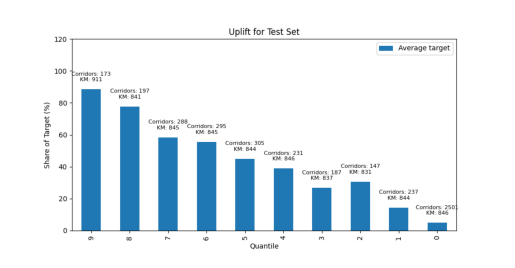

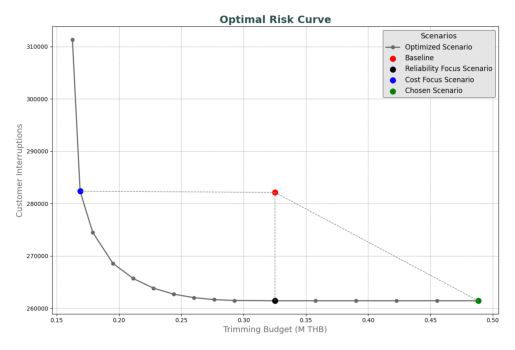

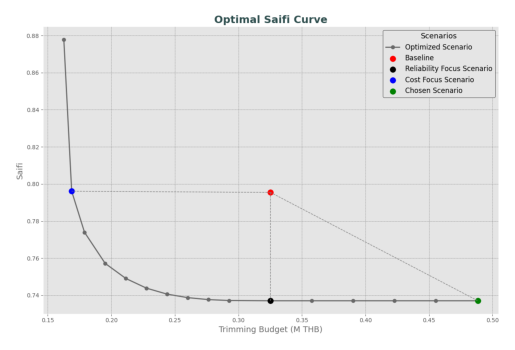

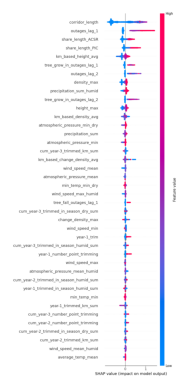

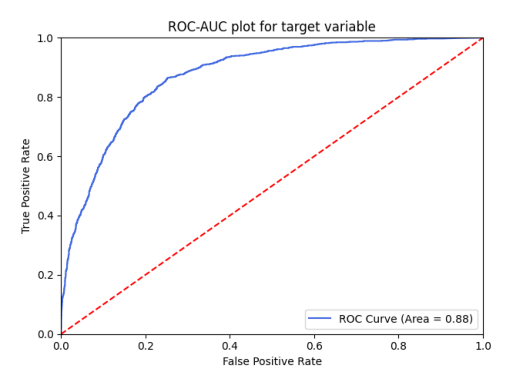

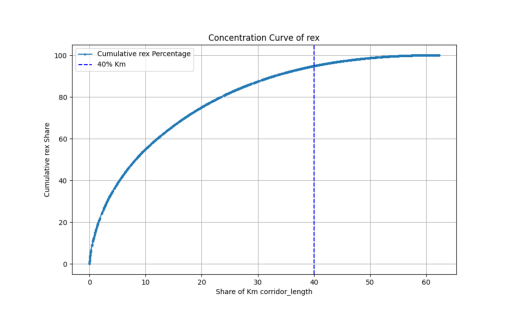

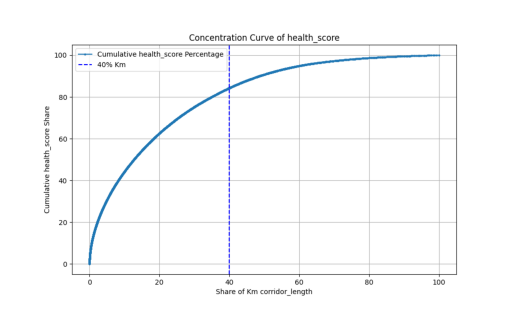

In [17]:
io_utils.load_and_save_images("model_outputs_decile_km_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("opti_curve_risk_image", "risk_modeling", local_path,  engine)
io_utils.load_and_save_images("opti_curve_saifi_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("model_outputs_shaps_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("roc_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("risk_concentration_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("model_outputs_health_concentration_image", "risk_modeling", local_path, engine)